# IY028 - Embedding Space Visualisation

This notebook visualises the experimental dual-channel IY028 feature/embedding spaces using:

1. Raw dual-channel time-series features used by the pure SVM baseline.
2. catch22 features extracted separately from mCherry and GFP, then concatenated.
3. Frozen SimCLR backbone embeddings from the best dual-channel checkpoint selected in `IY028_test_simclr_exp_data_dual.ipynb`.
4. SimCLR + SVM decision-score vectors from an RBF SVM fitted on the SimCLR embeddings.

The RBF SVM feature map is implicit, so the decision-score vector is the finite classifier-level representation visualised here.

Default task: classify `TF x glucose` for paired mCherry/GFP traces from `EXP-25-IY008/4_transformed_exp_time_series`.
The notebook also reports Discriminability D scores for each high-dimensional representation before 2D projection.

ARI and NMI clustering agreement metrics are reported in a separate section from the Discriminability D scores.


In [1]:
import sys
from pathlib import Path

_src_root = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src").exists() and (candidate / "experiments").exists()
)
sys.path.insert(0, str((_src_root / "src").resolve()))
from utils.paths import find_project_root

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pycatch22
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY028_DIR = EXP_DIR / "EXP-26-IY028"
DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series"
SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR.resolve()))
from models.ssl_transformer import SSL_Transformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]

# Best dual-channel score reported by IY028_test_simclr_exp_data_dual.ipynb: 0.7872 accuracy.
# The IY024 cross-view checkpoint is the default because it is tied for best and matches the paired-channel task.
BEST_SIMCLR_CKPT = EXP_DIR / "EXP-26-IY024" / "IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth"

# The old summary selected this IY017 checkpoint because duplicate short labels can overwrite tied entries.
TIED_IY017_CKPT = EXP_DIR / "EXP-26-IY017" / "IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_154043_model.pth"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()} -> {DATA_DIR}")
print(f"Checkpoint exists: {BEST_SIMCLR_CKPT.exists()} -> {BEST_SIMCLR_CKPT.name}")
print(f"Device: {DEVICE}")

Project root: /home/ianyang/stochastic_simulations
Data dir exists: True -> /home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series
Checkpoint exists: True -> IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth
Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Paired Experimental Traces

The six classes match the dual-channel IY028 notebooks: Nrg1 and Rtg1 strains at 2%, 0.1%, and 0.01% glucose. mCherry and GFP channels are kept separate until feature extraction.

In [2]:
FILE_PAIRS = [
    (
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series",
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series",
        0,
        "2% glucose",
        "Nrg1",
    ),
    (
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series",
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series",
        1,
        "0.1% glucose",
        "Nrg1",
    ),
    (
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series",
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series",
        2,
        "0.01% glucose",
        "Nrg1",
    ),
    (
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series",
        "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series",
        3,
        "2% glucose",
        "Rtg1",
    ),
    (
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series",
        "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series",
        4,
        "0.1% glucose",
        "Rtg1",
    ),
    (
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series",
        "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series",
        5,
        "0.01% glucose",
        "Rtg1",
    ),
]

LABEL_NAMES = {
    0: "Nrg1 @ 2% glucose",
    1: "Nrg1 @ 0.1% glucose",
    2: "Nrg1 @ 0.01% glucose",
    3: "Rtg1 @ 2% glucose",
    4: "Rtg1 @ 0.1% glucose",
    5: "Rtg1 @ 0.01% glucose",
}


def load_dual_channel_data(data_dir):
    """Load paired mCherry/GFP traces and truncate channels to common lengths."""
    if not data_dir.exists():
        raise FileNotFoundError(
            f"Missing data directory: {data_dir}\n"
            "Expected the IY008 transformed dual-channel CSVs used by IY028."
        )

    m_arrays, g_arrays, rows = [], [], []
    for mcherry_stem, gfp_stem, label, glucose, tf_name in FILE_PAIRS:
        mcherry_path = data_dir / f"{mcherry_stem}.csv"
        gfp_path = data_dir / f"{gfp_stem}.csv"
        if not mcherry_path.exists() or not gfp_path.exists():
            raise FileNotFoundError(f"Missing paired CSVs: {mcherry_path.name}, {gfp_path.name}")

        df_m = pd.read_csv(mcherry_path)
        df_g = pd.read_csv(gfp_path)
        time_cols_m = [c for c in df_m.columns if c not in META_COLS]
        time_cols_g = [c for c in df_g.columns if c not in META_COLS]

        # Keep only cells observed in both channels so paired rows stay aligned.
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))
        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]

        m_arrays.append(df_m[time_cols_m].to_numpy(float))
        g_arrays.append(df_g[time_cols_g].to_numpy(float))
        for cell_id in common_ids:
            rows.append({
                "cell_id": cell_id,
                "label": label,
                "class_name": LABEL_NAMES[label],
                "glucose": glucose,
                "tf": tf_name,
                "mcherry_stem": mcherry_stem,
                "gfp_stem": gfp_stem,
            })
        print(f"{LABEL_NAMES[label]:24s}: {len(common_ids):4d} paired cells")

    # Truncate each channel to its own common length before stacking experiments.
    min_tp_m = min(arr.shape[1] for arr in m_arrays)
    min_tp_g = min(arr.shape[1] for arr in g_arrays)
    X_m = np.vstack([arr[:, :min_tp_m] for arr in m_arrays])
    X_g = np.vstack([arr[:, :min_tp_g] for arr in g_arrays])
    metadata = pd.DataFrame(rows)
    return X_m, X_g, metadata, min_tp_m, min_tp_g


X_m_raw, X_g_raw, metadata_raw, min_tp_m, min_tp_g = load_dual_channel_data(DATA_DIR)
print(f"mCherry matrix: {X_m_raw.shape} ({min_tp_m} timepoints)")
print(f"GFP matrix    : {X_g_raw.shape} ({min_tp_g} timepoints)")
display(metadata_raw.groupby(["tf", "glucose", "class_name"]).size().rename("n").reset_index())

Nrg1 @ 2% glucose       :   84 paired cells
Nrg1 @ 0.1% glucose     :  231 paired cells
Nrg1 @ 0.01% glucose    :  231 paired cells
Rtg1 @ 2% glucose       :   78 paired cells
Rtg1 @ 0.1% glucose     :  200 paired cells
Rtg1 @ 0.01% glucose    :  275 paired cells
mCherry matrix: (1099, 89) (89 timepoints)
GFP matrix    : (1099, 80) (80 timepoints)


,tf,glucose,class_name,n
0,Nrg1,0.01% glucose,Nrg1 @ 0.01% glucose,231
1,Nrg1,0.1% glucose,Nrg1 @ 0.1% glucose,231
2,Nrg1,2% glucose,Nrg1 @ 2% glucose,84
3,Rtg1,0.01% glucose,Rtg1 @ 0.01% glucose,275
4,Rtg1,0.1% glucose,Rtg1 @ 0.1% glucose,200
5,Rtg1,2% glucose,Rtg1 @ 2% glucose,78


## Preprocess and Balance

NaNs are handled with deterministic IterativeImputer-based imputation. Classes are then subsampled to the minority class size, matching the IY028 downstream SVM notebooks.

In [3]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.imputation import fill_nans
from utils.processing.balancing import balance_by_label

# Impute channels separately so the two fluorescence traces keep their own structure.
X_m_clean = fill_nans(X_m_raw)
X_g_clean = fill_nans(X_g_raw)
X_m_bal, X_g_bal, metadata = balance_by_label(X_m_clean, X_g_clean, metadata_raw, RANDOM_STATE)

X_m_norm = StandardScaler().fit_transform(X_m_bal)
X_g_norm = StandardScaler().fit_transform(X_g_bal)

print(f"Balanced mCherry: {X_m_bal.shape}")
print(f"Balanced GFP    : {X_g_bal.shape}")
display(metadata["class_name"].value_counts().sort_index().rename_axis("class_name").reset_index(name="n"))

Balanced mCherry: (468, 89)
Balanced GFP    : (468, 80)


,class_name,n
0,Nrg1 @ 0.01% glucose,78
1,Nrg1 @ 0.1% glucose,78
2,Nrg1 @ 2% glucose,78
3,Rtg1 @ 0.01% glucose,78
4,Rtg1 @ 0.1% glucose,78
5,Rtg1 @ 2% glucose,78


## 0. Raw Pure-SVM Feature Space

The pure SVM baseline uses the truncated dual-channel time series directly as features. Here this raw feature matrix is scaled and projected with the same PCA/t-SNE workflow as catch22 and SimCLR.

In [4]:
raw_svm_features = np.concatenate([X_m_norm, X_g_norm], axis=1)
raw_svm_scaled = StandardScaler().fit_transform(raw_svm_features)
print(f"Raw pure-SVM feature matrix: {raw_svm_scaled.shape} ({X_m_norm.shape[1]} mCherry + {X_g_norm.shape[1]} GFP timepoints)")

Raw pure-SVM feature matrix: (468, 169) (89 mCherry + 80 GFP timepoints)


## 1. catch22 Feature Space

For the dual-channel task, catch22 is extracted independently from mCherry and GFP and then concatenated to form a 44-dimensional feature vector per cell.

In [5]:
def extract_catch22_features(X, prefix):
    """Return a catch22 feature DataFrame for an array of cell traces."""
    records = []
    feature_names = None
    # Prefix feature names by channel before concatenating mCherry and GFP features.
    for trace in tqdm(X, desc=f"catch22 {prefix}"):
        result = pycatch22.catch22_all(trace.tolist())
        if feature_names is None:
            feature_names = [f"{prefix}_{name}" for name in result["names"]]
        records.append(result["values"])
    features = pd.DataFrame(records, columns=feature_names).replace([np.inf, -np.inf], np.nan)
    return features.fillna(features.median(numeric_only=True)).fillna(0.0)


# Extract catch22 per channel, then concatenate to keep channel provenance explicit.
catch22_m = extract_catch22_features(X_m_bal, "mCherry")
catch22_g = extract_catch22_features(X_g_bal, "GFP")
catch22_features = pd.concat([catch22_m, catch22_g], axis=1)
catch22_scaled = StandardScaler().fit_transform(catch22_features)
print(f"catch22 feature matrix: {catch22_scaled.shape}")
display(catch22_features.head())

catch22 mCherry:   0%|          | 0/468 [00:00<?, ?it/s]

catch22 mCherry:  61%|██████    | 285/468 [00:00<00:00, 2842.44it/s]

catch22 mCherry: 100%|██████████| 468/468 [00:00<00:00, 2835.86it/s]

catch22 GFP:   0%|          | 0/468 [00:00<?, ?it/s]

catch22 GFP:  65%|██████▍   | 304/468 [00:00<00:00, 3034.21it/s]

catch22 GFP: 100%|██████████| 468/468 [00:00<00:00, 2997.02it/s]

catch22 feature matrix: (468, 44)


,mCherry_DN_HistogramMode_5,mCherry_DN_HistogramMode_10,mCherry_CO_f1ecac,mCherry_CO_FirstMin_ac,mCherry_CO_HistogramAMI_even_2_5,mCherry_CO_trev_1_num,mCherry_MD_hrv_classic_pnn40,mCherry_SB_BinaryStats_mean_longstretch1,mCherry_SB_TransitionMatrix_3ac_sumdiagcov,mCherry_PD_PeriodicityWang_th0_01,...,GFP_FC_LocalSimple_mean1_tauresrat,GFP_DN_OutlierInclude_p_001_mdrmd,GFP_DN_OutlierInclude_n_001_mdrmd,GFP_SP_Summaries_welch_rect_area_5_1,GFP_SB_BinaryStats_diff_longstretch0,GFP_SB_MotifThree_quantile_hh,GFP_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,GFP_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,GFP_SP_Summaries_welch_rect_centroid,GFP_FC_LocalSimple_mean3_stderr
0,-0.031556,-0.350073,0.777669,2,0.083476,-0.750546,0.965909,7.0,0.005337,7,...,0.111111,-0.0250,0.3250,0.542379,5.0,2.004744,0.78125,0.34375,0.392699,0.903695
1,0.437454,-0.238596,1.035870,3,0.071783,1.123911,0.920455,6.0,0.019818,7,...,0.083333,-0.5625,0.7000,0.695254,4.0,1.962759,0.81250,0.53125,0.196350,0.750848
2,-0.665121,-0.870014,7.585812,6,0.518408,0.161176,0.920455,24.0,0.111111,22,...,0.142857,0.2250,-0.1625,0.434483,5.0,2.133051,0.75000,0.81250,0.785398,0.968953
3,-0.419623,-0.689121,0.972740,2,0.124691,-0.790398,0.943182,16.0,0.057613,2,...,0.052632,0.7375,-0.7125,0.747899,4.0,1.878844,0.25000,0.81250,0.147262,0.599574
4,0.057631,-0.318956,0.870419,2,0.032497,1.472955,0.965909,6.0,0.010204,4,...,0.090909,0.2750,0.7375,0.755846,6.0,1.826571,0.18750,0.81250,0.147262,0.673102


## 2. Best SimCLR Embedding Space

The frozen SimCLR backbone encodes each channel separately. The mCherry and GFP embedding vectors are concatenated before visualisation, mirroring the dual-channel downstream SVM workflow.

In [6]:
from utils.embeddings import parse_arch_from_name, load_simclr_model, encode_channel

simclr_model = load_simclr_model(BEST_SIMCLR_CKPT, DEVICE)
Z_m = encode_channel(simclr_model, X_m_norm, DEVICE)
Z_g = encode_channel(simclr_model, X_g_norm, DEVICE)
# Concatenate channel embeddings to mirror the downstream dual-channel classifier input.
simclr_embeddings = np.concatenate([Z_m, Z_g], axis=1)
simclr_scaled = StandardScaler().fit_transform(simclr_embeddings)
print(f"mCherry embedding: {Z_m.shape}")
print(f"GFP embedding    : {Z_g.shape}")
print(f"Dual embedding   : {simclr_scaled.shape}")

SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

mCherry embedding: (468, 16)
GFP embedding    : (468, 16)
Dual embedding   : (468, 32)


## 3. SimCLR + SVM Decision-Score Space

An RBF SVM does not expose a finite feature embedding because its kernel space is implicit. To visualise the fitted SimCLR + SVM model, use the per-class decision-score vector returned by `SVC.decision_function` as a classifier-level representation.

In [7]:
simclr_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    decision_function_shape="ovr",
    random_state=RANDOM_STATE,
)
simclr_svm.fit(simclr_scaled, metadata["label"].to_numpy())
simclr_svm_scores = simclr_svm.decision_function(simclr_scaled)
if simclr_svm_scores.ndim == 1:
    simclr_svm_scores = simclr_svm_scores[:, None]
simclr_svm_score_scaled = StandardScaler().fit_transform(simclr_svm_scores)
print(f"SimCLR + SVM decision-score matrix: {simclr_svm_score_scaled.shape}")

SimCLR + SVM decision-score matrix: (468, 6)


## Compute Discriminability D Scores

D is computed on the scaled high-dimensional representation matrices before PCA or t-SNE. It compares all between-class pairwise Euclidean distances against all within-class pairwise distances, with larger positive values indicating stronger class separation.


In [8]:
from utils.metrics import discriminability_d_score

representation_matrices = {
    "Raw SVM features": raw_svm_scaled,
    "catch22": catch22_scaled,
    "SimCLR": simclr_scaled,
    "SimCLR + SVM scores": simclr_svm_score_scaled,
}

labels = metadata["label"].to_numpy()
d_score_df = pd.DataFrame(
    [
        {"representation": name, **discriminability_d_score(matrix, labels)}
        for name, matrix in representation_matrices.items()
    ]
)
d_score_path = IY028_DIR / "IY028_embedding_space_discriminability.csv"
d_score_df.to_csv(d_score_path, index=False)
print(f"Saved: {d_score_path}")
display(
    d_score_df.assign(
        D_score=lambda df: df["D_score"].map(lambda x: f"{x:.2g}"),
        mean_within_distance=lambda df: df["mean_within_distance"].map(lambda x: f"{x:.2g}"),
        mean_between_distance=lambda df: df["mean_between_distance"].map(lambda x: f"{x:.2g}"),
        pooled_distance_sd=lambda df: df["pooled_distance_sd"].map(lambda x: f"{x:.2g}"),
    )
)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_discriminability.csv


,representation,D_score,mean_within_distance,mean_between_distance,pooled_distance_sd,n_within_pairs,n_between_pairs
0,Raw SVM features,1,12,18,6,18018,91260
1,catch22,0.2,8.6,9.1,2.6,18018,91260
2,SimCLR,0.85,5.3,7.8,2.9,18018,91260
3,SimCLR + SVM scores,1.8,1.4,3.5,1.2,18018,91260


## Compute Clustering Agreement Metrics (ARI and NMI)

ARI and NMI are computed by clustering each scaled high-dimensional representation with KMeans using the true number of classes, then comparing cluster assignments against the known labels. These metrics are separate from Discriminability D: they measure unsupervised cluster-label agreement rather than pairwise distance separation.


In [9]:
from utils.metrics import clustering_agreement_metrics

clustering_metrics_df = pd.DataFrame(
    [
        {"representation": name, **clustering_agreement_metrics(matrix, labels, RANDOM_STATE)}
        for name, matrix in representation_matrices.items()
    ]
)
clustering_metrics_path = IY028_DIR / "IY028_embedding_space_clustering_metrics.csv"
clustering_metrics_df.to_csv(clustering_metrics_path, index=False)
print(f"Saved: {clustering_metrics_path}")
display(
    clustering_metrics_df.assign(
        ARI=lambda df: df["ARI"].map(lambda x: f"{x:.2g}"),
        NMI=lambda df: df["NMI"].map(lambda x: f"{x:.2g}"),
        kmeans_inertia=lambda df: df["kmeans_inertia"].map(lambda x: f"{x:.2g}"),
    )
)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_clustering_metrics.csv


,representation,ARI,NMI,n_clusters,kmeans_inertia
0,Raw SVM features,0.42,0.53,6,2.9e+04
1,catch22,0.089,0.15,6,1.4e+04
2,SimCLR,0.32,0.46,6,5e+03
3,SimCLR + SVM scores,0.44,0.57,6,2.9e+02


## Reduce to Two Dimensions

PCA gives a deterministic linear view. t-SNE gives a nonlinear neighbourhood view; use PCA for global structure and t-SNE for local separation. Each representation is scaled independently before reduction.

In [10]:
from utils.embeddings import reduce_embeddings

projections = {
    "Raw SVM features": reduce_embeddings(raw_svm_scaled, "Raw SVM features", RANDOM_STATE),
    "catch22": reduce_embeddings(catch22_scaled, "catch22", RANDOM_STATE),
    "SimCLR": reduce_embeddings(simclr_scaled, "SimCLR", RANDOM_STATE),
    "SimCLR + SVM scores": reduce_embeddings(simclr_svm_score_scaled, "SimCLR + SVM scores", RANDOM_STATE),
}

Raw SVM features PCA explained variance: 0.75


    SGD-MDS may not have converged: stress changed by -1.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.


catch22 PCA explained variance: 0.36


    SGD-MDS may not have converged: stress changed by -15.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR PCA explained variance: 0.60


    SGD-MDS may not have converged: stress changed by 1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR + SVM scores PCA explained variance: 0.83


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 12 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


## Plot Embedding Spaces

Each point is one paired cell. Colour shows the six `TF x glucose` classes, and marker style separates TF strains.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_visualisation.png


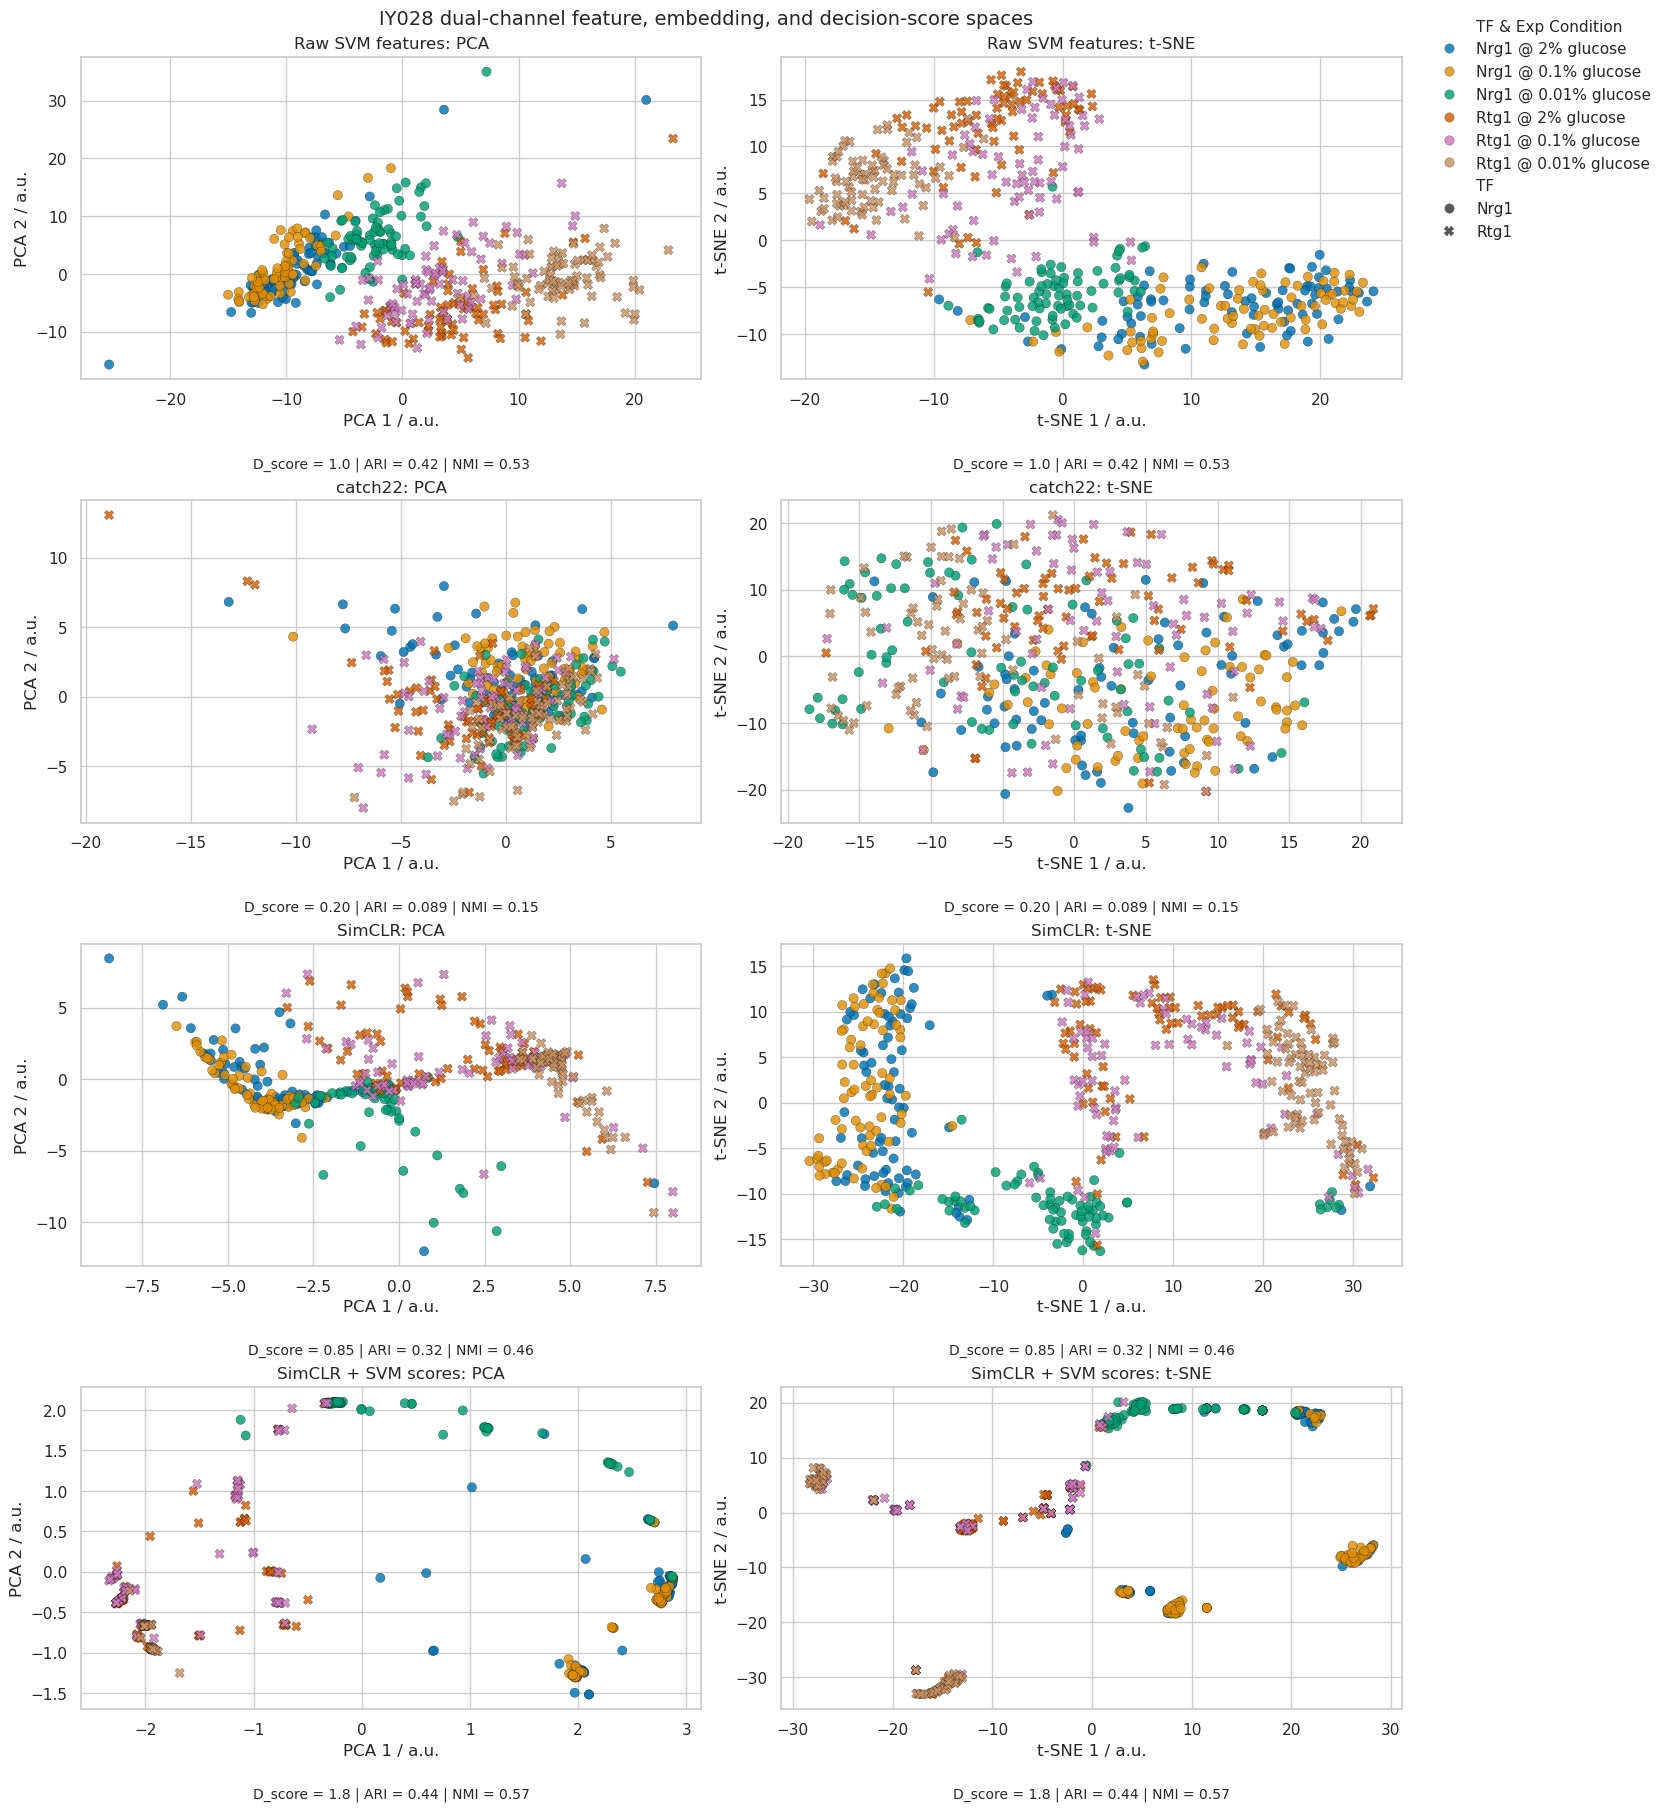

In [11]:
from utils.embeddings import projection_frame

embedding_metric_df = (
    pd.read_csv(IY028_DIR / "IY028_embedding_space_discriminability.csv")
    .merge(
        pd.read_csv(IY028_DIR / "IY028_embedding_space_clustering_metrics.csv")
        [["representation", "ARI", "NMI"]],
        on="representation",
        how="inner",
    )
    .set_index("representation")
)


def format_metric_value(value):
    """Return a two-significant-figure metric string without dropping trailing zeros."""
    return np.format_float_positional(value, precision=2, unique=False, fractional=False, trim="k")


def embedding_metric_label(representation):
    """Format representation-level separation and clustering metrics for a subplot."""
    row = embedding_metric_df.loc[representation]
    return (
        f"D_score = {format_metric_value(row['D_score'])} | "
        f"ARI = {format_metric_value(row['ARI'])} | "
        f"NMI = {format_metric_value(row['NMI'])}"
    )


def add_embedding_metric_annotation(ax, representation):
    """Place representation-level metrics below one embedding axes."""
    ax.text(
        0.5,
        -0.24,
        embedding_metric_label(representation),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        clip_on=False,
    )


representation_order = ["Raw SVM features", "catch22", "SimCLR", "SimCLR + SVM scores"]
method_order = ["PCA", "t-SNE"]
# Build one long plotting table so every panel uses identical metadata columns.
plot_df = pd.concat(
    [
        projection_frame(projections[representation][method], metadata, representation, method)
        for representation in representation_order
        for method in method_order
    ],
    ignore_index=True,
)
# Add IY028-specific display aliases used by seaborn hue/style.
plot_df["TF & Exp Condition"] = plot_df["class_name"]
plot_df["TF"] = plot_df["tf"]

fig, axes = plt.subplots(
    len(representation_order),
    len(method_order),
    figsize=(14, 4.5 * len(representation_order)),
    constrained_layout=True,
    squeeze=False,
)
axes = np.asarray(axes)

for row, representation in enumerate(representation_order):
    for col, method in enumerate(method_order):
        ax = axes[row, col]
        df_sub = plot_df[(plot_df["representation"] == representation) & (plot_df["method"] == method)]
        sns.scatterplot(
            data=df_sub,
            x="x",
            y="y",
            hue="TF & Exp Condition",
            style="TF",
            s=45,
            alpha=0.82,
            linewidth=0.2,
            edgecolor="black",
            ax=ax,
        )
        ax.set_title(f"{representation}: {method}")
        ax.set_xlabel(f"{method} 1 / a.u.")
        ax.set_ylabel(f"{method} 2 / a.u.")
        add_embedding_metric_annotation(ax, representation)
        # Remove per-panel legends; a single figure-level legend is added below.
        ax.legend_.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
fig.suptitle("IY028 dual-channel feature, embedding, and decision-score spaces", fontsize=14)

out_path = IY028_DIR / "IY028_embedding_space_visualisation.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_visualisation_t-SNE.png


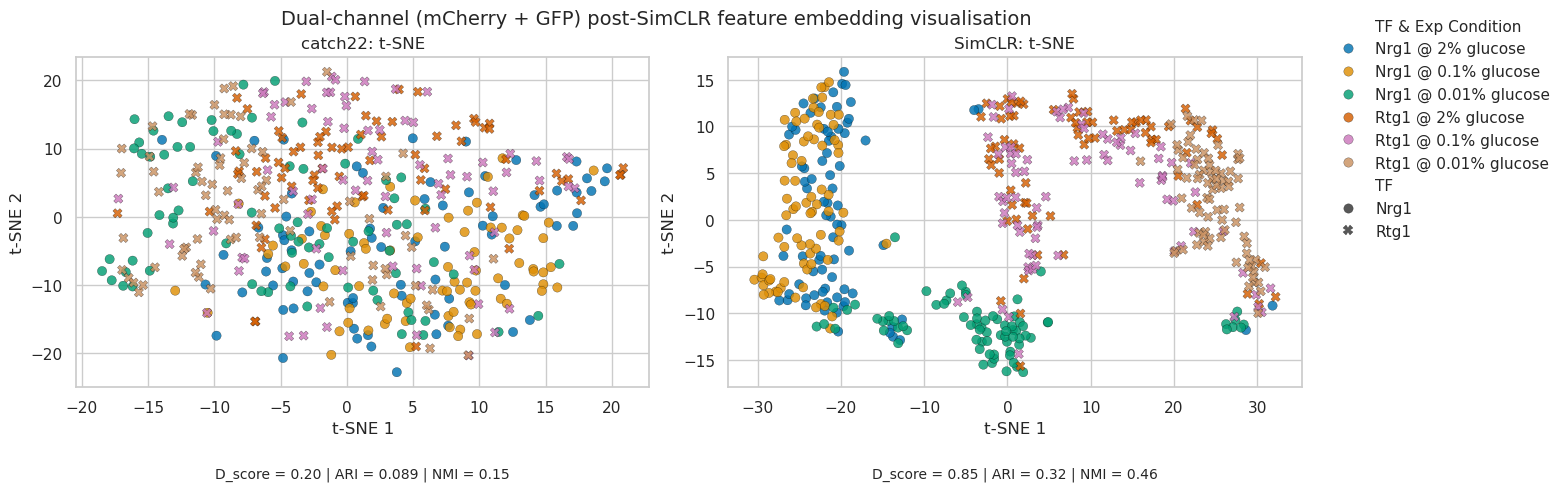

In [12]:
representation_order = ["catch22", "SimCLR"]
method_order = ["t-SNE"]
# Build one long plotting table so every panel uses identical metadata columns.
plot_df = pd.concat(
    [
        projection_frame(projections[representation][method], metadata, representation, method)
        for representation in representation_order
        for method in method_order
    ],
    ignore_index=True,
)
# Add IY028-specific display aliases used by seaborn hue/style.
plot_df["TF & Exp Condition"] = plot_df["class_name"]
plot_df["TF"] = plot_df["tf"]

fig, axes = plt.subplots(
    len(method_order),
    len(representation_order),
    figsize=(6.5 * len(representation_order), 4.8 * len(method_order)),
    constrained_layout=True,
    squeeze=False,
)
axes = np.asarray(axes)

for row, method in enumerate(method_order):
    for col, representation in enumerate(representation_order):
        ax = axes[row, col]
        df_sub = plot_df[(plot_df["representation"] == representation) & (plot_df["method"] == method)]
        sns.scatterplot(
            data=df_sub,
            x="x",
            y="y",
            hue="TF & Exp Condition",
            style="TF",
            s=45,
            alpha=0.82,
            linewidth=0.2,
            edgecolor="black",
            ax=ax,
        )
        ax.set_title(f"{representation}: {method}")
        ax.set_xlabel(f"{method} 1")
        ax.set_ylabel(f"{method} 2")
        add_embedding_metric_annotation(ax, representation)
        # Remove per-panel legends; a single figure-level legend is added below.
        ax.legend_.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
fig.suptitle("Dual-channel (mCherry + GFP) post-SimCLR feature embedding visualisation", fontsize=14)

out_path = IY028_DIR / "IY028_embedding_space_visualisation_t-SNE.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## Optional: Save Coordinates

The reduced coordinates are useful for checking individual cells or replotting in another tool.

In [13]:
coords_path = IY028_DIR / "IY028_embedding_space_coordinates.csv"
plot_df.to_csv(coords_path, index=False)
print(f"Saved: {coords_path}")
display(plot_df.head())

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_coordinates.csv


,cell_id,label,class_name,glucose,tf,mcherry_stem,gfp_stem,x,y,representation,method,TF & Exp Condition,TF
0,1346_4_004;100;1,0,Nrg1 @ 2% glucose,2% glucose,Nrg1,19316_2020_10_26_steadystate_glucose_144m_2w2_...,19316_2020_10_26_steadystate_glucose_144m_2w2_...,-10.670763,-9.906141,catch22,t-SNE,Nrg1 @ 2% glucose,Nrg1
1,1346_4_004;12;1,0,Nrg1 @ 2% glucose,2% glucose,Nrg1,19316_2020_10_26_steadystate_glucose_144m_2w2_...,19316_2020_10_26_steadystate_glucose_144m_2w2_...,-4.871837,-7.527860,catch22,t-SNE,Nrg1 @ 2% glucose,Nrg1
2,1346_4_004;16;1,0,Nrg1 @ 2% glucose,2% glucose,Nrg1,19316_2020_10_26_steadystate_glucose_144m_2w2_...,19316_2020_10_26_steadystate_glucose_144m_2w2_...,17.091690,-1.319153,catch22,t-SNE,Nrg1 @ 2% glucose,Nrg1
3,1346_4_004;18;1,0,Nrg1 @ 2% glucose,2% glucose,Nrg1,19316_2020_10_26_steadystate_glucose_144m_2w2_...,19316_2020_10_26_steadystate_glucose_144m_2w2_...,-13.955004,11.282265,catch22,t-SNE,Nrg1 @ 2% glucose,Nrg1
4,1346_4_004;22;1,0,Nrg1 @ 2% glucose,2% glucose,Nrg1,19316_2020_10_26_steadystate_glucose_144m_2w2_...,19316_2020_10_26_steadystate_glucose_144m_2w2_...,-9.875257,8.928483,catch22,t-SNE,Nrg1 @ 2% glucose,Nrg1
